## Домашнее задание №7

##### Автор: [Радослав Нейчев](https://www.linkedin.com/in/radoslav-neychev/), @neychev

In [1]:
import numpy as np

import torch
from torch import nn
from torch.nn import functional as F

import torchvision
from torchvision.datasets import MNIST

from matplotlib import pyplot as plt
from IPython.display import clear_output

### Задача №1: 
Обратимся к классической задаче распознавания рукописных цифр. Мы будем работать с набором данных [MNIST](http://yann.lecun.com/exdb/mnist/). В данном задании воспользуемся всем датасетом целиком.

__Ваша основная задача: реализовать весь пайплан обучения модели и добиться качества $\geq 92\%$ на тестовой выборке.__

Код для обучения модели в данном задании отсутствует. Присутствует лишь несколько тестов, которые помогут вам отладить свое решение. За примером можно обратиться к ноутбуку первого занятия.

Настоятельно рекомендуем написать код "с нуля", лишь поглядывая на готовые примеры, а не просто "скопировать-вставить". Это поможет вам в дальнейшем.

Text(0.5, 1.0, 'Image label: 7')

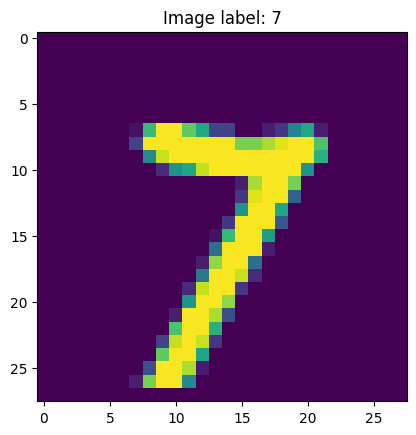

In [2]:
# do not change the code in the block below
# __________start of block__________

train_mnist_data = MNIST(
    ".", train=True, transform=torchvision.transforms.ToTensor(), download=True
)
test_mnist_data = MNIST(
    ".", train=False, transform=torchvision.transforms.ToTensor(), download=True
)


train_data_loader = torch.utils.data.DataLoader(
    train_mnist_data, batch_size=32, shuffle=True, num_workers=2
)

test_data_loader = torch.utils.data.DataLoader(
    test_mnist_data, batch_size=32, shuffle=False, num_workers=2
)

random_batch = next(iter(train_data_loader))
_image, _label = random_batch[0][0], random_batch[1][0]
plt.figure()
plt.imshow(_image.reshape(28, 28))
plt.title(f"Image label: {_label}")
# __________end of block__________

Постройте модель ниже. Пожалуйста, не стройте переусложненную сеть, не стоит делать ее глубже четырех слоев (можно и меньше). Ваша основная задача – обучить модель и получить качество на отложенной (тестовой выборке) не менее 92% accuracy.

*Комментарий: для этого достаточно линейных слоев и функций активации.*

__Внимание, ваша модель должна быть представлена именно переменной `model`.__

In [3]:
# Creating model instance
class NN(nn.Module):
    def __init__(self):
        super(NN, self).__init__()
        self.fc1 = nn.Linear(784, 100)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(100, 10)


    def forward(self, x):
        x = self.fc1(x)
        x = self.relu(x)
        x = self.fc2(x)
        x = self.relu(x)
        return x

    
    
model = NN()  # your code here

In [4]:
class SimpleModel(nn.Module):
    def __init__(self):
        super(SimpleModel, self).__init__()
        self.fc1 = nn.Linear(784, 300)
        self.relu1 = nn.ReLU()

        self.fc2 = nn.Linear(300, 150)
        self.relu2 = nn.ReLU()

        self.fc3 = nn.Linear(150, 100)
        self.relu3 = nn.ReLU()

        self.fc4 = nn.Linear(100, 10)


    def forward(self, x):
        x = self.fc1(x)
        x = self.relu1(x)

        x = self.fc2(x)
        x = self.relu2(x)

        x = self.fc3(x)
        x = self.relu3(x)

        x = self.fc4(x)

        return x

model = SimpleModel()
        

Локальные тесты для проверки вашей модели доступны ниже:

In [5]:
# do not change the code in the block below
# __________start of block__________
assert model is not None, "Please, use `model` variable to store your model"

try:
    x = random_batch[0].reshape(-1, 784)
    y = random_batch[1]

    # compute outputs given inputs, both are variables
    y_predicted = model(x)
except Exception as e:
    print("Something is wrong with the model")
    raise e


assert y_predicted.shape[-1] == 10, "Model should predict 10 logits/probas"

print("Everything seems fine!")
# __________end of block__________

Everything seems fine!


Настройте параметры модели на обучающей выборке. Рекомендуем поработать с различными оптимизаторами.

In [11]:
criterion = nn.CrossEntropyLoss()
optimaizer = torch.optim.Adam(model.parameters(), lr=0.001)
num_epochs = 3

loss_list = []

for epochs in range(num_epochs):
    model.train()
    runniing_loss = 0
    for batch in train_data_loader:
        inputs, labels = batch[0].reshape(-1, 784), batch[1]

        optimaizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)

        loss.backward()
        optimaizer.step()

        runniing_loss += loss.item()
    loss_list.append(runniing_loss / len(train_data_loader))
    print(f'Epoch [{epochs+1}/{num_epochs}], Loss: {runniing_loss/len(train_data_loader):.4f}')


Epoch [1/3], Loss: 0.2490
Epoch [2/3], Loss: 0.0997
Epoch [3/3], Loss: 0.0691


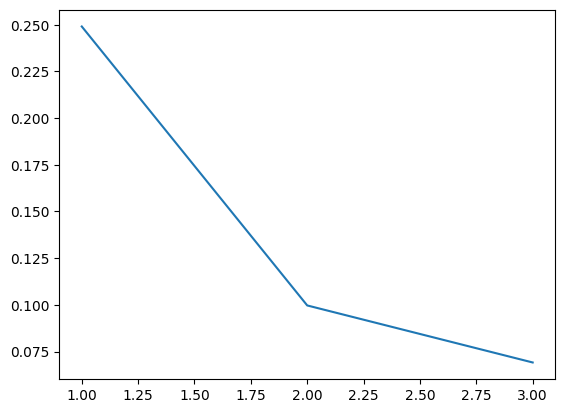

In [12]:
import matplotlib.pyplot as plt

plt.plot(range(1, num_epochs + 1), loss_list)
plt.show()

Также, напоминаем, что в любой момент можно обратиться к замечательной [документации](https://pytorch.org/docs/stable/index.html) и [обучающим примерам](https://pytorch.org/tutorials/).  

Оценим качество классификации:

In [13]:
predicted_labels = []
real_labels = []
model.eval()
with torch.no_grad():
    for batch in train_data_loader:
        y_predicted = model(batch[0].reshape(-1, 784))
        predicted_labels.append(y_predicted.argmax(dim=1))
        real_labels.append(batch[1])

predicted_labels = torch.cat(predicted_labels)
real_labels = torch.cat(real_labels)
train_acc = (predicted_labels == real_labels).type(torch.FloatTensor).mean()

In [14]:
print(f"Neural network accuracy on train set: {train_acc:3.5}")

Neural network accuracy on train set: 0.98692


In [15]:
predicted_labels = []
real_labels = []
model.eval()
with torch.no_grad():
    for batch in test_data_loader:
        y_predicted = model(batch[0].reshape(-1, 784))
        predicted_labels.append(y_predicted.argmax(dim=1))
        real_labels.append(batch[1])

predicted_labels = torch.cat(predicted_labels)
real_labels = torch.cat(real_labels)
test_acc = (predicted_labels == real_labels).type(torch.FloatTensor).mean()

In [16]:
print(f"Neural network accuracy on test set: {test_acc:3.5}")

Neural network accuracy on test set: 0.977


Проверка, что необходимые пороги пройдены:

In [17]:
assert test_acc >= 0.92, "Test accuracy is below 0.92 threshold"
assert (
    train_acc >= 0.91
), "Train accuracy is below 0.91 while test accuracy is fine. We recommend to check your model and data flow"

### Сдача задания
Загрузите файл `hw07_data_dict.npy` (ссылка есть на странице с заданием) и запустите код ниже для генерации посылки.

In [32]:
# do not change the code in the block below
# __________start of block__________
import os

assert os.path.exists('hw03_data_dict.npy'), 'Please, download `hw03_data_dict.npy` and place it in the working directory'

def get_predictions(model, eval_data, step=10):
    
    predicted_labels = []
    model.eval()
    with torch.no_grad():
        for idx in range(0, len(eval_data), step):
            y_predicted = model(eval_data[idx:idx+step].reshape(-1, 784))
            predicted_labels.append(y_predicted.argmax(dim=1))
    
    predicted_labels = torch.cat(predicted_labels)
    return predicted_labels

loaded_data_dict = np.load('hw03_data_dict.npy', allow_pickle=True)

submission_dict = {
    'train': get_predictions(model, torch.FloatTensor(loaded_data_dict.item()['train'])).numpy(),
    'test': get_predictions(model, torch.FloatTensor(loaded_data_dict.item()['test'])).numpy()
}

np.save('submission_dict_hw03.npy', submission_dict, allow_pickle=True)
print('File saved to `submission_dict_hw03.npy`')
# __________end of block__________

File saved to `submission_dict_hw03.npy`


In [29]:
# do not change the code in the block below
# __________start of block__________
import os
import json

assert os.path.exists(
    "hw03_data_dict.npy"
), "Please, download `hw07_data_dict.npy` and place it in the working directory"


def get_predictions(model, eval_data, step=10):

    predicted_labels = []
    model.eval()
    with torch.no_grad():
        for idx in range(0, len(eval_data), step):
            y_predicted = model(eval_data[idx : idx + step].reshape(-1, 784))
            predicted_labels.append(y_predicted.argmax(dim=1))

    predicted_labels_np = torch.cat(predicted_labels).numpy()
    predicted_labels_str = ",".join([str(x) for x in list(predicted_labels)])
    return predicted_labels_np, predicted_labels_str


loaded_data_dict = np.load("hw07_data_dict.npy", allow_pickle=True)

train_labels_np, train_labels_str = get_predictions(
    model, torch.FloatTensor(loaded_data_dict.item()["train"])
)
test_labels_np, test_labels_str = get_predictions(
    model, torch.FloatTensor(loaded_data_dict.item()["test"])
)

submission_dict_str = {
    "train": train_labels_str,
    "test": test_labels_str,
}

submission_dict_np = {
    "train": train_labels_np,
    "test": test_labels_np,
}

np.save("submission_dict_hw03.npy", submission_dict_np, allow_pickle=True)
with open("submission_dict_hw03.json", "w") as iofile:
    json.dump(submission_dict_str, iofile)
print("File saved to `submission_dict_hw03.json` and `submission_dict_hw03.npy`")
# __________end of block__________

File saved to `submission_dict_hw03.json` and `submission_dict_hw03.npy`


На этом задание завершено. Поздравляем!

In [21]:
# Замените блок сохранения на этот:
import json

# Убедитесь, что используете правильное имя файла (hw03 вместо hw07)
with open("submission_dict_hw03.json", "w", encoding="utf-8") as iofile:
    json.dump(submission_dict_str, iofile, ensure_ascii=False)

print("File saved to `submission_dict_hw03.json`")

# Исправьте все вхождения hw07 на hw03
# loaded_data_dict = np.load("hw03_data_dict.npy", allow_pickle=True)


# Добавьте проверку валидности JSON
import json
try:
    test_json = json.dumps(submission_dict_str)
    print("JSON is valid")
except Exception as e:
    print("JSON error:", e)

    

File saved to `submission_dict_hw03.json`
JSON is valid


In [23]:
with open("submission_dict_hw07.json", "w", encoding="utf-8") as iofile:
    json.dump(submission_dict_str, iofile, ensure_ascii=False, indent=4)

In [35]:
# Преобразуйте метки в строки с явным указанием кодировки
predicted_labels_str = ",".join([str(x) for x in list(predicted_labels)])

In [36]:
# Сохраняем только JSON
with open("submission_dict_hw03.json", "w", encoding="utf-8") as iofile:
    json.dump(submission_dict_str, iofile, ensure_ascii=False)

In [37]:

# Добавьте проверку
import json
test_json = json.dumps(submission_dict_str)
print("JSON is valid:", test_json[:100])

JSON is valid: {"train": "tensor([0, 9, 0, 2, 8, 5, 7, 9, 4, 4]),tensor([0, 5, 7, 2, 0, 2, 4, 5, 5, 8]),tensor([7, 
